[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/3_BackProp_and_ReLU.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 5 (M2.1) - Learning a whole dataset (stochastic gradient descent)

- Refresher: one row, P-E-D-W (predict, error, delta, weight update) on 3 weights.
- A flat weight line means that input was 0 and never contributed - nice teachable moment in the plot.
- Learn ALL the rows: update after every row = stochastic gradient descent. 14 rows x 100 epochs = 1,400 tiny updates; error falls fast and flattens near 7.5.
- SAY WHY it can't hit zero: the data has CONTRADICTORY days (same weather, both outcomes). No model beats that. Great reasonable-person-test moment.
- GD flavors: stochastic (per row), full (per epoch), batch (in between - and THAT's the batch_size hyperparameter they'll type in Keras next week).
- Cliffhanger: stacking linear layers is pointless (2x2x2 is just x8). We need nonlinearity - next video.
-->

#  Learning an entire dataset with forward and backpropagation with nonlinear activation functions
-----------------------------------------
**Dr. Dave Wanik - University of Connecticut - Department of Operations and Information Management**

You almost have everything you need to understand how a neural network fits! Now let's kick it up a notch and see how we can include nonlinearity into the mix via the `relu` activation and learn an entire dataset.

In [1]:
# get some important modules
import pandas as pd # for data wrangling
import numpy as np # for array calculations, some math functions
from matplotlib import pyplot as plt #for plotting

In [2]:
# some modules for neural nets
from keras.models import Sequential
from keras.layers import Dense

# Read and Prepare Data

Let's read some nice dummy data for this example. Some basic categorical data for a classification problem.

In [3]:
# # step 1: copy & paste the shared link you will get from Google Drive
# URL = 'https://drive.google.com/file/d/1rVwxy0fd-9aM2Dvw8_42hWoZ7upZE0jt/view?usp=sharing'

# # step 2: copy & paste the command below (this part of the command is fixed)
# fixed_path = 'https://drive.google.com/uc?export=download&id='

# # step 3: Extract the file ID from the URL (this part of the command is fixed)
# file_path = URL.split('/')[-2]

# # retrieve the CSV data and build a dataframe
# df = pd.read_csv(fixed_path + file_path)

# # print the shape and dataset info
# print(df.shape)
# df.info()

In [4]:
# our made-up golf logbook - this time the way a human would write it down: in WORDS.
# (inline in the notebook, so the data can never change under you)
weather = pd.DataFrame({
    'Day':      ['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14'],
    'Temp':     ['hot','hot','hot','cool','cool','cool','cool','cool','cool','cool','cool','cool','hot','cool'],
    'Humidity': ['humid','humid','humid','humid','dry','dry','dry','humid','dry','dry','dry','humid','dry','humid'],
    'Wind':     ['calm','windy','calm','calm','calm','windy','windy','calm','calm','calm','windy','windy','calm','windy'],
    'Play':     ['no','no','yes','yes','yes','no','yes','no','yes','yes','yes','yes','yes','no'],
})
print(weather.shape)
weather.info()

(14, 5)
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Day       14 non-null     str  
 1   Temp      14 non-null     str  
 2   Humidity  14 non-null     str  
 3   Wind      14 non-null     str  
 4   Play      14 non-null     str  
dtypes: str(5)
memory usage: 932.0 bytes


But computers can't 'read' categorical data! A dot product has no idea what to do with the word 'hot' - we need to recode the weather into something a computer can perform mathematical operations on.

So first let's look at the data the way the golf course logbook would actually record it - in words - and then translate it into 0s and 1s ourselves. This little translation step is the same move you'll make on every real dataset you ever touch.

In [5]:
# here is the logbook - could YOU spot the pattern of when people play?
weather

,Day,Temp,Humidity,Wind,Play
0,D1,hot,humid,calm,no
1,D2,hot,humid,windy,no
2,D3,hot,humid,calm,yes
3,D4,cool,humid,calm,yes
4,D5,cool,dry,calm,yes
5,D6,cool,dry,windy,no
6,D7,cool,dry,windy,yes
7,D8,cool,humid,calm,no
8,D9,cool,dry,calm,yes
9,D10,cool,dry,calm,yes


In [6]:
# a dot product can't multiply 'hot' - translate the words into math!
# 1 = hot / humid / windy / played, 0 = cool / dry / calm / stayed home
golf = weather.replace({'hot': 1, 'cool': 0,
                        'humid': 1, 'dry': 0,
                        'windy': 1, 'calm': 0,
                        'yes': 1, 'no': 0})

golf = golf[['Temp', 'Humidity', 'Wind', 'Play']].astype(int)  # replace() keeps the object dtype - cast, or dot products complain
golf

,Temp,Humidity,Wind,Play
0,1,1,0,0
1,1,1,1,0
2,1,1,0,1
3,0,1,0,1
4,0,0,0,1
5,0,0,1,0
6,0,0,1,1
7,0,1,0,0
8,0,0,0,1
9,0,0,0,1


In [7]:
# check your work - every column is numeric now, ready for dot products
print(golf.dtypes)
print()
print('rows x columns:', golf.shape)

Temp        int64
Humidity    int64
Wind        int64
Play        int64
dtype: object

rows x columns: (14, 4)


This notebook considers how a network learns an entire dataset. Consider you are a big fan of golf. You can decide whether or not to play by watching the weather. Which weather combinations indicate when folks are playing?

To solve this problem, you might record the temperature, humidity and wind speed observing the correlation between each weather and playing golf.

Since neural networks do not read the pattern of weather, we have to translate the weather into math. What you really want to do is mimic the pattern of the weather in the form of numbers. Notice that the pattern of numbers shown here mimics the pattern from the weather in the form of 0s and 1s. Each weather condition (temperature, humidity and wind speed) gets a column. Notice also that there are 14 rows representing the 14 different observed weather.

# Refresher: Learning One Row of Data

You have converted the weather pattern into a matrix ( with just 0s and 1s). Now let’s create that matrix in Python so the neural network can read it. What do you want the neural network to do? Take the weather matrix and learn to transform it into the play_vs_noplay matrix. More important, you want the neural network to take any matrix containing the same underlying pattern as weather and transform it into a matrix that contains the underlying pattern of play_vs_noplay.

In [8]:
# building a neural network

import numpy as np

# let's choose some random initial values for the weights
weights = np.array([0.52,0.18,-0.12])
alpha = 0.1 # some small number, a learning rate

# X data
X = golf.loc[:, ['Temp', 'Humidity', 'Wind']] # select temp, humidity and wind as inputs
X = np.array(X.values.tolist()) # generate those values in array

# y data
y = np.array(golf['Play'].tolist()) # convert play in array

# specify one row of data to predict - scroll up and check golf to confirm
input = X[0] # [1,1,0] # select the first row (D1: hot, humid, calm - no play)
target_var = y[0] # 0 means no play

print('this is the first row of data:', input)
print('this is the target variable for first row:', target_var)

this is the first row of data: [1 1 0]
this is the target variable for first row: 0


Remember PEDW:
* make a prediction
* calculate the (squared) error
* calculate weight delta (direction and amount)
* update the weight (weights get adjusted such that we make a more accurate prediction next time!)

If we previously overestimated, weights need to get smaller (more negative). If we previously underestimated, the weights need to get bigger (more positive.)

In [9]:
# let's fit the model
my_weights = []
my_error = []
for iteration in range(20):
    prediction = input.dot(weights)
    error = (target_var - prediction) ** 2
    delta = prediction - target_var
    weights = weights - (alpha * (input * delta))
    my_weights.append(weights)
    my_error.append(error)
    print("Error:" + str(error) + " Prediction:" + str(prediction))

Error:0.48999999999999994 Prediction:0.7
Error:0.31360000000000005 Prediction:0.56
Error:0.20070400000000002 Prediction:0.448
Error:0.12845056 Prediction:0.3584
Error:0.08220835840000001 Prediction:0.28672000000000003
Error:0.05261334937600001 Prediction:0.22937600000000002
Error:0.03367254360064001 Prediction:0.18350080000000002
Error:0.02155042790440961 Prediction:0.14680064000000004
Error:0.01379227385882215 Prediction:0.11744051200000002
Error:0.008827055269646177 Prediction:0.09395240960000002
Error:0.005649315372573553 Prediction:0.07516192768000002
Error:0.0036155618384470737 Prediction:0.060129542144000014
Error:0.0023139595766061252 Prediction:0.04810363371519999
Error:0.0014809341290279209 Prediction:0.03848290697216
Error:0.000947797842577868 Prediction:0.03078632557772798
Error:0.0006065906192498355 Prediction:0.024629060462182384
Error:0.00038821799631989475 Prediction:0.019703248369745907
Error:0.0002484595176447323 Prediction:0.015762598695796715
Error:0.0001590140912926

Of course, we know error goes down as we train. This smooth and gentle curve is a hallmark of a model that isn't training too quickly (training too quickly might lead to overfitting!)

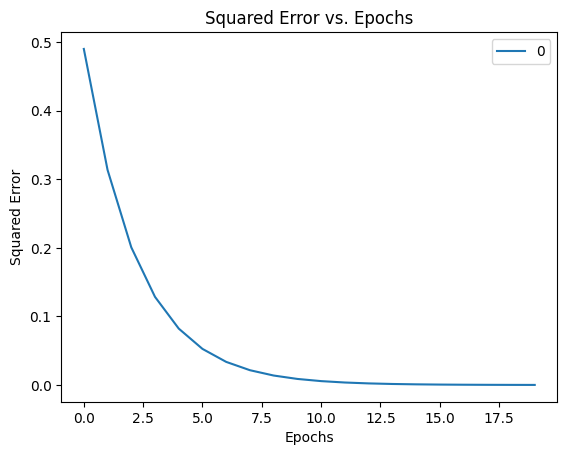

In [10]:
my_error = pd.DataFrame(my_error)
my_error.plot()
plt.xlabel('Epochs')
plt.ylabel('Squared Error')
plt.title('Squared Error vs. Epochs')
plt.show()

Let's investigate how the weights changed... TWO weights moved (Temp and Humidity - their inputs were both 1), and the Wind weight is a flat line the whole way. Why? Its input was 0, and the P-E-D-W update scales by the input - **an input of zero sends no information, so its weight never gets updated.**

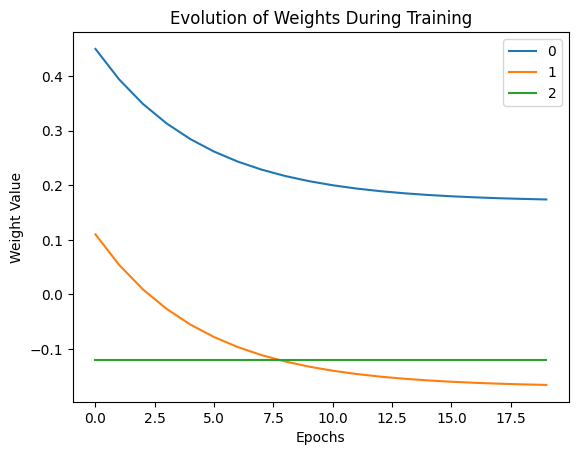

In [11]:
# see how the value of the weights changed?
my_weights = pd.DataFrame(my_weights)
my_weights.plot()
plt.xlabel('Epochs')
plt.ylabel('Weight Value')
plt.title('Evolution of Weights During Training')
plt.show()

💡Recall the PEDW code... you scale the weight by the input... so if the input is ZERO - no weight update! This is because it did not send any information forward across the network... so why would you update its weight?! This one really is a lightbulb moment... this explains why the GREEN line (the Wind weight) is flat for input data of [1,1,0]... a 0 means no information was sent!

# Learning the whole dataset!

In the previous example, you have trained neural networks that learned how to model a single training example (input ▶ target_variable pair). But now you’re trying to build a neural network that tells you whether it is a play. You need it to know more than one weather. How do you do this? You train it on all the weather data at once.

Below is a wonderful example of **stochastic gradient descent** - the weights are updated after every single row! You should be able to tell this is stochastic gradient descent just by looking at the code.

In [12]:
import numpy as np

# feel free to try other values!
weights = np.array([0.5,0.48,-0.7])
# feel free to try other values!
alpha = 0.1

# X data
X = golf.loc[:, ['Temp', 'Humidity', 'Wind']] # select temp, humidity and wind as inputs
X = np.array(X.values.tolist()) # generate those values in array

# y data
y = np.array(golf['Play'].tolist()) # convert play in array

# a place to store results (so we can graph later!)
my_weights = []
my_error = []

for iteration in range(100): # train for 100 epochs!
    error_for_all = 0 # a place to store sq. error after each observation
    for row_index in range(len(y)):
        input = X[row_index]
        target_var = y[row_index]

        prediction = input.dot(weights)

        error = (target_var - prediction) ** 2
        # check track of the squared error
        error_for_all += error

        delta = prediction - target_var
        weights = weights - (alpha * (input * delta))
        print("Prediction:" + str(prediction))


    print("Error:" + str(error_for_all) + "\n")
    my_error.append(error_for_all)
    # store results
    my_weights.append(weights)

Prediction:0.98
Prediction:0.08400000000000007
Prediction:0.7672
Prediction:0.39688
Prediction:0.0
Prediction:-0.7083999999999999
Prediction:-0.6375599999999999
Prediction:0.45719200000000004
Prediction:0.0
Prediction:0.0
Prediction:-0.4738039999999999
Prediction:0.0850492000000001
Prediction:0.41688000000000003
Prediction:0.2680393600000001
Error:11.198970642609849

Prediction:0.9513559440000001
Prediction:0.4993522992
Prediction:0.66121429536
Prediction:0.364971690144
Prediction:0.0
Prediction:-0.31166768591999994
Prediction:-0.2805009173279999
Prediction:0.4284745211296
Prediction:0.0
Prediction:0.0
Prediction:-0.15245082559519993
Prediction:0.3484213259809601
Prediction:0.36399974614400005
Prediction:0.4787370607847681
Error:8.979260489994468

Prediction:0.8305110018696673
Prediction:0.644487219783481
Prediction:0.5355113575390376
Prediction:0.30186027242084856
Prediction:0.0
Prediction:-0.08437030369060085
Prediction:-0.07593327332154076
Prediction:0.3716742451787637
Prediction:0.

## Visualize your results

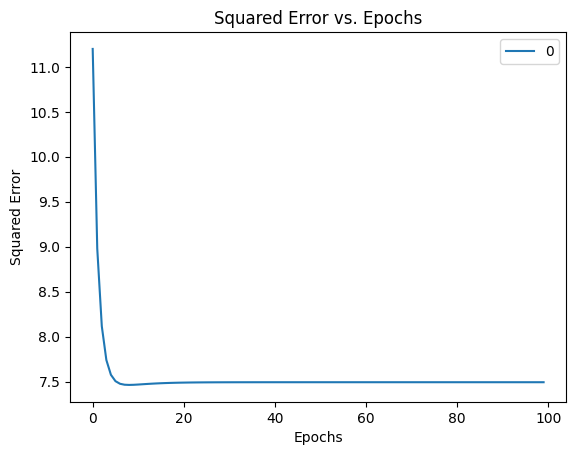

In [13]:
my_error = pd.DataFrame(my_error)
my_error.plot()
plt.xlabel('Epochs')
plt.ylabel('Squared Error')
plt.title('Squared Error vs. Epochs')
plt.show()

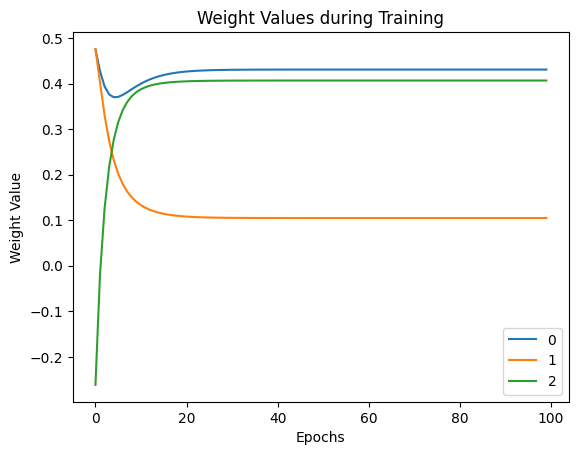

In [14]:
# see how the value of the weights changed?
my_weights = pd.DataFrame(my_weights)
my_weights.plot()
plt.xlabel('Epochs')
plt.ylabel('Weight Value')
plt.title('Weight Values during Training')
plt.show()

Don't you love the wiggly lines? Your model LEARNED an entire dataset! THAT IS AWESOME! But look closely: the error falls fast and then plateaus around **7.5** - it will never reach zero. Two reasons, and both are worth internalizing: (1) our data has **contradictory days** - the same weather appears with Play = yes AND Play = no - so no model on Earth can drive this error to zero; (2) a single layer can only learn *direct* correlation, and this pattern doesn't fully have it. Hold that 7.5 in your head - we'll beat it with a hidden layer and ReLU at the end of this notebook.

Your model is updating its weights to make an accurate prediction for all 14 rows of data.
.
While this sort of looks like a nonlinear weight update (because of the wiggly lines),  we haven't truly introduced what makes a neural network truly nonlinear, which is the inclusion of activation functions in the hidden layers... coming soon!

**On Your Own:** See if you can keep track of the predictions during each iteration and make a plot of accuracy. Make a confusion matrix or classification report after each epoch.

## The Various Types of Gradient Descent

1.   **Stochastic**: Learning "one example at a time" is a variant on Gradient Descent called Stochastic Gradient Descent, and it is one of the handful of methods that can be used for learning an entire dataset. This is the example we use in this notebook.
2.   **Full**: Instead of updating the weights once for each training example, the network simply calculates the average weight_delta over the entire dataset, only actually changing the weights each time it computes a full average.
3.   **Batch**: Instead of updating the weights after just one or after the entire dataset of examples, you choose a "batch size" (typically between 8 and 256) after which the weights are updated.




**On Your Own:** We will focus on stochastic gradient descent in this notebook. You can try to update the code to account for full and batch gradient descent by hand and compare!

### so... which one should I use?
Like all good questions: it depends.

*   **Stochastic** - every row gets a say IMMEDIATELY. Fast feedback... but you may end up nitpicking each individual row (noise included!) instead of going for the general trend.
*   **Full** - update once per pass over ALL the rows. Stable, but slow feedback - and you can get stuck.
*   **Batch** - the compromise, and the industry default. Update every 8-256 rows... and THAT is the `batch_size` you will be typing into Keras in the very next notebook!

# Learning Indirect Correlation

We just got done training a single-layer neural network to take a weather pattern and identify whether people will play golf or not. Let's take on the neural network's perspective for a moment: it doesn't know that it was processing weather data. All it was trying to do was identify which input (out of the 3 possible) correlated with the output - it updates the weights to relate input to output.

... but what if there is no clear or obvious pattern relating the input to the output?

If your data does NOT have direct correlation, you should create intermediate data that does. In reality, neural networks search for correlation between their input and output layers. You set the values of the input layer to be individual rows of the input data, and you try to train the network (update weights) so that the output layer equals the output dataset. The neural network doesn’t know about data (neural networks aren't 'smart'.) - NNs just search for correlation between the input and output layers.

💡 Now we are starting to talk about hidden layers in earnest 😀  Let's use two set of weights in our network. The first one will create an intermediate dataset that has indirect correlation with our output (where we will introduce a nonlinear activation function). The second will then use that indirect correlation to correctly predict our output with a linear activation function (so that it can take on any value.)

# No difference between these dot products

### Three layer example
There are two mathematical operations using three layers:
* `np.dot(a,b)`
* `np.dot(tmp,c)`

In [15]:
a = [-5, 1, 3, -7, 2]

b = [[2, 2, 2, 2, 2],
     [2, 2, 2, 2, 2],
     [2, 2, 2, 2, 2],
     [2, 2, 2, 2, 2],
     [2, 2, 2, 2, 2]] # make this a 5x5 matrix!

c = [[3],
     [3],
     [3],
     [3],
     [3]] # make this a 5x1 matrix!

tmp = np.dot(a,b)
tmp = np.dot(tmp,c)
tmp

array([-180])

### Two layer example
There is one mathematical operations using two layers:
* `np.dot(a,b)`

... yet we get the same answer. So why bother having a third layer?

In [16]:
a = [-5, 1, 3, -7, 2]

b = [[30],
     [30],
     [30],
     [30],
     [30]] # make this a 5x1 matrix!
np.dot(a,b)

array([-180])

### Same answer, but with less layers... what can we do?
It's a linear combination - so we can do whatever we need to do with two layers instead of three. Those multiple sets of dot products are no different than multiply 2*3*4 or just multiplying 2*12... the latter is simpler, takes less time, and is accurate - so you should use that one!

We will need nonlinearity in order to have any value from stacking layers so that we can learn 'indirect correlation' where the input sometimes correlates to the output and sometimes does not.

This is where activation functions come in!

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 6 (M2.1) - ReLU and backpropagation, end to end

- ReLU: recode negatives to zero. That's it. The simplest possible nonlinearity - and it's what makes deep networks worth stacking.
- During backprop, ReLU's derivative means ONLY weights whose input was >0 get updated - credit goes to the paths that carried information.
- Walk ONE full backward pass out loud: underestimate -> GROW the contributing weight (0.756 -> 0.786) -> layer-2 delta becomes layer-1 delta.
- Then learn the whole set with ReLU: error falls ~9.4 -> ~5.5, clearly beating the single layer's 7.5 - the hidden layer earned its keep.
- If asked why not lower: contradictory days + no bias terms (the all-zeros day can only ever be predicted 0).
- CLOSE M2.1: everything Keras does next video, you have now done by hand. .fit() is officially not magic anymore.
- (Optional whiteboard capstone if energy allows: draw a 3-4-1 net, count 21 params, trace one forward+backward pass - the old PuttingItAllTogether video.)
-->

# Nonlinearity and activation functions (ReLU!)
[Rectified linear unit](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) (ReLU) is just one of several activation functions we will get to know during our class. It is one of the simplest functions and very important for allowing our model to learn nonlinear patterns.

![relu](https://miro.medium.com/max/357/1*oePAhrm74RNnNEolprmTaQ.png)

**Figure:** An image showing how ReLU recodes values - if the value is less than 0, it gets recoded to 0. Otherwise, return x.

In [17]:
# original data
a = [-5, 1, 3, -7, 2]
# relu function! if it's negative, return a 0, otherwise, return original value
np.maximum(a, 0)

array([0, 1, 3, 0, 2])

a      : [-6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8  9 10 11]
ReLU(a): [ 0  0  0  0  0  0  0  1  2  3  4  5  6  7  8  9 10 11]


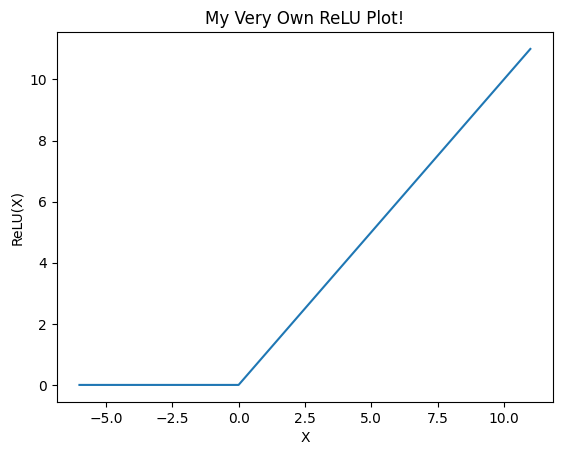

In [18]:
# make your own ReLU plot!
a = np.arange(-6,12,1)
print('a      :', a)
# relu function! if it's negative, return a 0, otherwise, return original value
b = np.maximum(a, 0)
print('ReLU(a):', b)
plt.plot(a,b)
plt.title('My Very Own ReLU Plot!')
plt.xlabel('X')
plt.ylabel('ReLU(X)')
plt.show()

ReLU simply recodes a value to zero if it has a negative number. This simple activation function (and others like it) are responsible for allowing neural networks to learn in a nonlinear way.

# Our First "Deep" Neural Network

The following code initializes the weights and makes a forward propagation. Our first neural network with its 16 (12 + 4) neuron weights and 4 hidden units in the hidden layer.

In [19]:
!pip3 install keras-visualizer
from keras import models
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation
from keras_visualizer import visualizer
from keras import layers

model = models.Sequential()
model.add(Dense(4, input_shape=(3,))) # the 4 is for the number of hidden layers, the 3 is size of the input data
model.add(Dense(1))



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary() # inspect for output shapes and trainable parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
try:
    visualizer(model, file_format='png', view=True)
except Exception as e:
    # renders fine on Colab (graphviz preinstalled); on a bare machine install graphviz first
    print('keras_visualizer needs the graphviz binary to draw the png -', e)

keras_visualizer needs the graphviz binary to draw the png - [Keras Visualizer] Error while visualizing: <class 'Exception'>


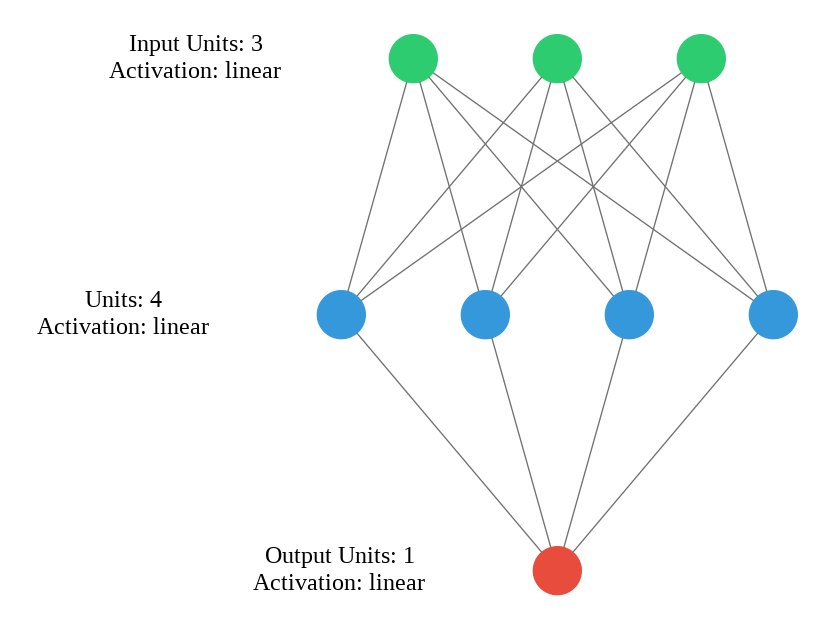

## What ReLU does during Forward Propagation

In [22]:
import numpy as np

np.random.seed(1)

# 1. Initializing the network's weights and data
def relu(x):
    return (x > 0) * x # returns x if x > 0
                       # return 0 otherwise

def relu2deriv(output):
    return output>0 # returns 1 for input > 0
                    # return 0 otherwise

# X data
X = golf.loc[:, ['Temp', 'Humidity', 'Wind']] # select temp, humidity and wind as inputs
X = np.array(X.values.tolist()) # generate those values in array

# y data
y = np.array(golf['Play'].tolist()).T

alpha = 0.1 # learning rate
hidden_size = 4 # 4 hidden units in the hidden layer

# input/target variable - day D13 (row 12): hot, dry, calm... and they played!
# this row makes a great demo: watch which hidden nodes light up
input = X[12:13]
target_var = y[12:13]

# randomly initialize the weights to start
weights_0_1 = 2*np.random.random((3,hidden_size))-1 # this is the number of columns in X (you don't have to hardcode)
weights_1_2 = 2*np.random.random((hidden_size,1))-1

# 2. PREDICT + COMPARE: Making a prediction, and calculating the output error and delta
# 3. LEARN: Backpropagation from layer_2 to layer_1

# P
layer_0 = input
layer_1 = np.dot(layer_0,weights_0_1)
print('layer_1 before RELU:', layer_1)
layer_1 = relu(layer_1)
print('layer_1 after RELU:', layer_1)
layer_2 = np.dot(layer_1,weights_1_2)

layer_1 before RELU: [[-0.16595599  0.44064899 -0.99977125 -0.39533485]]
layer_1 after RELU: [[-0.          0.44064899 -0.         -0.        ]]


See how the negative values were turned to 0s?! Note that `relu` is only used between hidden layers - you don't use `relu` going to `layer_2` (the output layer). We will eventually use different activation functions there.

Note that the only node that is going to communicate ANY information to the output is node2 (0.44). The rest got ReLU'd to 0! And look at the input: only Temp was a 1 on this day, so Temp alone built node2.

In [23]:
# layer 2
print('prediction:', layer_2)
print('target variable:', target_var)

prediction: [[0.33323413]]
target variable: [1]


Looks like we UNDERestimated! We predicted about 0.33 and they actually played (target = 1). Let's use this error feedback signal to update our model.

## Using ReLU During Backpropagation
We are working ourselves backwards from prediction to input and updating the weights as we go!

## Updating `weights_1_2`
We need to update our weights - we UNDERestimated! The weight that carried information needs to get BIGGER, so the next prediction comes out higher.

`layer_2_delta` is easy - it's just predicted minus actual: 0.33 - 1 = about **-0.67**. A negative delta means we underestimated.

In [24]:
# E (remember - this is just used for tracking model fit)
error = (layer_2-target_var)**2
print('error:', error)
# D (direction and amount)
# predicted minus actual - NEGATIVE here, meaning we UNDERestimated
layer_2_delta=(layer_2-target_var) # [1,1] shape

print('layer_2_delta:', layer_2_delta)

error: [[0.44457672]]
layer_2_delta: [[-0.66676587]]


And it would be fine to update layer_2 weights at this point.

In [25]:
weights_1_2

array([[-0.5910955 ],
       [ 0.75623487],
       [-0.94522481],
       [ 0.34093502]])

In [26]:
weight_delta_1_2 = layer_1.T.dot(layer_2_delta)
print('weight_delta_1_2: \n', weight_delta_1_2)

weight_delta_1_2: 
 [[ 0.       ]
 [-0.2938097]
 [ 0.       ]
 [ 0.       ]]


Remember that node2 of layer1 was the only node to pass some information... hence, it's the only weight in weight1_2 that should be updated!

In [27]:
print('before: \n', weights_1_2)
print('\n')
weights_1_2 -= alpha * weight_delta_1_2
print('after: \n', weights_1_2) # node 2's weight gets BIGGER! the rest stay frozen

before: 
 [[-0.5910955 ]
 [ 0.75623487]
 [-0.94522481]
 [ 0.34093502]]


after: 
 [[-0.5910955 ]
 [ 0.78561584]
 [-0.94522481]
 [ 0.34093502]]


What you see is that the 0.756 weight (in the second node) has become about 0.786 - it got BIGGER! This makes sense because our model underpredicted by about 0.67, and node2 was the only messenger carrying information to the output - so we turn its contribution UP.

And which weight moved? ONLY the one that carried information. The first, third and fourth weights didn't budge - their nodes were 0s in layer_1, they sent nothing forward, so they earn no update back!

In [28]:
# see? only the second node in layer1 had any info to pass to the prediction
layer_1

array([[-0.        ,  0.44064899, -0.        , -0.        ]])

## Updating `weights_0_1`

We already know `layer_2_delta` has a [1,1] shape - it is just a constant (about -0.67). It tells our model we underestimated by 0.67! Let's use this information as a feedback signal to create `layer_1_delta` and update the `weights_0_1`.

🛑 This is more involved than the previous weight update. Pay attention and make sure you work the math out by hand to confirm your understanding.

## weights_1_2 helps update weights_0_1

As a refresher, here are the weights_1_2 (from layer 1 to layer 2 prediction layer)

* The second and fourth weights are positive (which means any input into the seocnd and fourth unit would result in a larger output (think of a positive number times a positive number!)
  * Recall that we just underestimated. As such, we should push the weights that carried information UP (so that the prediction gets bigger).

* The first and third weights are negative (which means any input into the first and third node would result in a smaller output (think of a positive number times a negative number!)
  * Again, recall that we just underestimated by about 0.67. As such, we should push the weights that carried information in the direction that RAISES the prediction (so that the prediction gets less positive).


In [29]:
weights_1_2.T

array([[-0.5910955 ,  0.78561584, -0.94522481,  0.34093502]])

But also recall that it was the second node in `weights_1_2` that contributed any information. Hence, only weights that touched the second node should be updated.

In [30]:

# 4. LEARN: Generating weight_deltas, and updating weights
# W

# i added spaces here to make it line up nicely

# the delta flows backward through the same weights that carried the signal forward
print('layer_1                        :', layer_1)

layer_1_delta=layer_2_delta.dot(weights_1_2.T)
print('layer_1_delta before relu2deriv:', layer_1_delta)

layer_1_delta = layer_1_delta*relu2deriv(layer_1)
print('layer_1_delta after relu2deriv :', layer_1_delta)

layer_1                        : [[-0.          0.44064899 -0.         -0.        ]]
layer_1_delta before relu2deriv: [[ 0.39412231 -0.52382183  0.63024364 -0.22732384]]
layer_1_delta after relu2deriv : [[ 0.         -0.52382183  0.         -0.        ]]


See the four values in `layer_1_delta before relu2deriv` (about 0.39, -0.52, 0.63, -0.23)? Those are what the deltas WOULD be if every node had fired. These correspond to how we would decrease positive weights by this amount - these weights in weight_1_2 were positive, so the model wants to literally make the output smaller because we had overestimated!

But nodes 1, 3 and 4 of layer_1 were 0 after ReLU - they sent nothing forward - so relu2deriv masks their deltas out. Hence, we will only update weights that touch node2 in layer_1.

This is why the -0.52 for node2 is the only value that survives in `layer_1_delta` - we are going to use this value to update only the weights that touched the second unit of `layer_1`.

❗ Take a breath and know that we are crushing it at this point - we know the model underestimated. And we are only going to update the weights that affected node2 of layer1 - these are the only input/weight pairs that contributed any information to the model! Leave the other weights alone.

In [31]:
# now update the weights using the deltas!
# these have the same shape as weights_1_2 and weights_0_1

weight_delta_0_1 = layer_0.T.dot(layer_1_delta)
print(weight_delta_0_1)


[[ 0.         -0.52382183  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


**On Your Own:** Looking at this matrix, you should be able to tell that you are updating ONLY the weight from Temperature to Node2 - Humidity and Wind were 0 on this day, so they sent no information forward and earn no update back! Draw this and show how the weights change!

In [32]:
# now update the weights with subtraction!
weights_0_1 -= alpha * weight_delta_0_1
print(weights_0_1)

[[-0.16595599  0.49303117 -0.99977125 -0.39533485]
 [-0.70648822 -0.81532281 -0.62747958 -0.30887855]
 [-0.20646505  0.07763347 -0.16161097  0.370439  ]]


If you scroll up, you will see the Temp-to-node2 weight in weights_0_1 got BIGGER (about 0.44 to 0.49) - and every other weight is untouched!

# [optional] The whole backward pass in one place

For completeness, here is one code cell that completes the ENTIRE iteration you just walked through - initialization, the forward pass, and the backward pass with ReLU - all in one place, ready to copy.

**On Your Own:** Add print statements to look at the shape of each variable as it goes by. This will help confirm your understanding of how data is transformed!

In [33]:
import numpy as np

np.random.seed(1)

# 1. Initializing the network's weights and data
def relu(x):
    return (x > 0) * x # returns x if x > 0
                       # return 0 otherwise

def relu2deriv(output):
    return output>0 # returns 1 for input > 0
                    # return 0 otherwise

# X data
X = golf.loc[:, ['Temp', 'Humidity', 'Wind']] # select temp, humidity and wind as inputs
X = np.array(X.values.tolist()) # generate those values in array

# y data
y = np.array(golf['Play'].tolist()).T

alpha = 0.1 # learning rate
hidden_size = 4 # 4 hidden units in the hidden layer

# randomly intialize the weights (between -1 and +1 so we don't have divergence)
weights_0_1 = 2*np.random.random((3,hidden_size))-1 # this is the number of columns in X (you don't have to hardcode)
weights_1_2 = 2*np.random.random((hidden_size,1))-1

# input/target variable - day D13 (row 12): hot, dry, calm... and they played!
# this row makes a great demo: watch which hidden nodes light up
input = X[12:13]
target_var = y[12:13]


# 2. PREDICT + COMPARE: Making a prediction, and calculating the output error and delta
# 3. LEARN: Backpropagation from layer_2 to layer_1

# P
layer_0 = input # first row of X
layer_1 = np.dot(layer_0,weights_0_1)
layer_1 = relu(layer_1)
layer_2 = np.dot(layer_1,weights_1_2)

# E
error = (layer_2-target_var)**2

# D
layer_2_delta=(layer_2-target_var)

# 4. LEARN: Generating weight_deltas, and updating weights
# W
layer_1_delta=layer_2_delta.dot(weights_1_2.T)
layer_1_delta *= relu2deriv(layer_1)

weight_delta_1_2 = layer_1.T.dot(layer_2_delta)
weight_delta_0_1 = layer_0.T.dot(layer_1_delta)

weights_1_2 -= alpha * weight_delta_1_2
weights_0_1 -= alpha * weight_delta_0_1

# Now, learn the entire dataset (update the weights) with ReLU

You can learn the amount that each weight contributes to the final error. Remember, the goal here is error attribution. It's all about figuring out how much each weight contributed to the final error. In our first (2-layer) neural network, we calculated a delta variable, which told us how much higher or lower we wanted the output prediction to be. Look at the code here. We compute our layer_2_delta in the same way. Nothing new here! (Again, go back to the previous chapter if you've forgotten how that part works.)

So, now that we have how much we want the final prediction to move up or down (delta), we need to figure out how much we want each middle (layer_1) node to move up or down. These are effectively intermediate predictions. Once we have the delta at layer_1, we can use all the same processes we used before for calculating a weight update (for each weight, multiply its input value by its output delta and increase the weight value by that much).

So, how do we calculate the deltas for layer_1? Well, first we do the obvious as mentioned on the previous pages, we multiply the output delta by each weight attached to it. This gives us a weighting of how much each weight contributed to that error. There's one more thing we need to factor in. If the relu set the output to a layer_1 node to be 0, then it didn't contribute to the error at all . So, when this was true, we should also set the delta of that node to be zero. Multiplying each layer_1 node by the relu2deriv function accomplishes this. relu2deriv is either a 1 or a 0 depending on whether the layer_1 value was > 0 or not.


In [34]:
import numpy as np

np.random.seed(3) # this seed gives a lively learning curve (seed 1 starts with mostly-dead ReLU units and barely moves)

# relu activation function for forward propagation
def relu(x):
    return (x > 0) * x # returns x if x > 0
                       # return 0 otherwise

# relu activation derivative for backpropagation
def relu2deriv(output):
    return output>0 # returns 1 for input > 0
                    # return 0 otherwise

# X data
X = golf.loc[:, ['Temp', 'Humidity', 'Wind']] # select temp, humidity and wind as inputs
X = np.array(X.values.tolist()) # generate those values in array

# y data
y = np.array(golf['Play'].tolist()).T

# a small learning rate
alpha = 0.1
# a hidden layer with 4 units!
hidden_size = 4

# randomly initialize weights
weights_0_1 = 2*np.random.random((3,hidden_size))-1 # this is the number of columns in X (you don't have to hardcode)
weights_1_2 = 2*np.random.random((hidden_size,1))-1

# a place to store results
my_weights_0_1 = []
my_weights_1_2 = []
my_error = []

for iteration in range(100): # train for 100 epochs
   layer_2_error = 0
   for i in range(len(y)): # stochastic gradient descent
      layer_0 = X[i:i+1]
      layer_1 = relu(np.dot(layer_0,weights_0_1))
      layer_2 = np.dot(layer_1,weights_1_2) # the value is layer_2 delta (target_var - prediction)

      layer_2_error += np.sum((layer_2 - y[i:i+1]) ** 2)

      layer_2_delta = (y[i:i+1] - layer_2)
      layer_1_delta = layer_2_delta.dot(weights_1_2.T)*relu2deriv(layer_1) # they are actually weighted versions of the layer_2 delta

      weights_1_2 += alpha * layer_1.T.dot(layer_2_delta) # made up some weight values so you can see how the layer_2 delta passes through them
      weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)


   if(iteration % 10 == 9):
      print("Error:" + str(layer_2_error))
   # store the error at the end of each epoch
   my_error.append(layer_2_error)
   # store the results at the end of each epoch
   my_weights_0_1.append(weights_0_1.flatten())
   my_weights_1_2.append(weights_1_2.flatten())


Error:7.7422531979646605

Error:7.469009949566708
Error:6.687385998671665
Error:6.159536689759633
Error:5.761251738030666


Error:5.5657804332384595


Error:5.541546745264942
Error:5.525425842014185
Error:5.512829576083761
Error:5.507534991574574


## Visualize your results

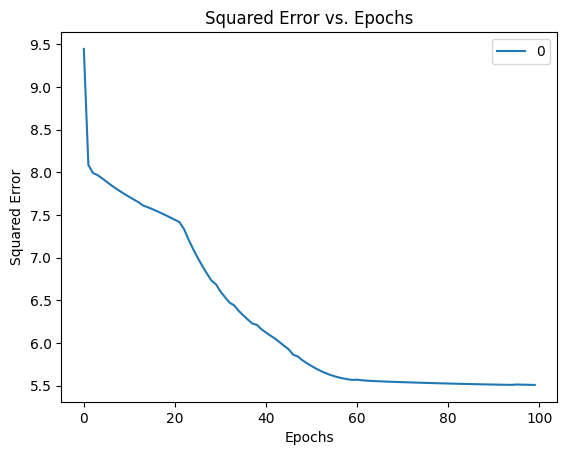

In [35]:
my_error = pd.DataFrame(my_error)
my_error.plot()
plt.xlabel('Epochs')
plt.ylabel('Squared Error')
plt.title('Squared Error vs. Epochs')
plt.show()

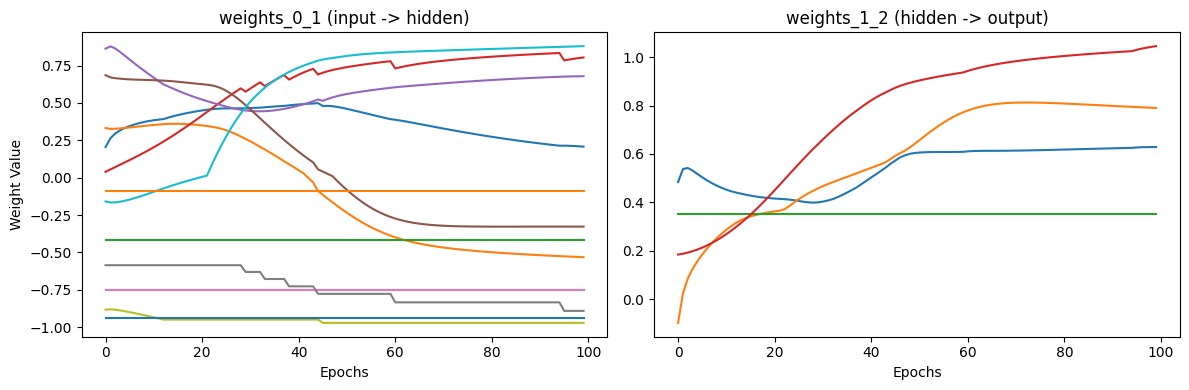

In [36]:
# both weight matrices, side by side - watch the network divide up the blame
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.DataFrame(my_weights_0_1).plot(ax=axes[0], legend=False)
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Weight Value')
axes[0].set_title('weights_0_1 (input -> hidden)')

pd.DataFrame(my_weights_1_2).plot(ax=axes[1], legend=False)
axes[1].set_xlabel('Epochs')
axes[1].set_title('weights_1_2 (hidden -> output)')

plt.tight_layout()
plt.show()

When the loss function starts to level off (flat line)... you have converged! Here the error falls from about **9.4 to 5.5** - and remember the single-layer network plateaued at **7.5**, so the hidden layer + ReLU genuinely learned indirect patterns a single layer could not. Why doesn't it go lower? Our contradictory days set a hard floor, and this little network has **no bias terms** - so for the all-calm, all-cool, all-dry day ([0,0,0]) it can only ever predict 0. Architecture choices have consequences! Using a smaller alpha and training longer helps, but note that more weights and layers don't automatically make a more accurate model. More on that later.

# On Your Own

**On Your Own:** See if you can add another hidden layer to this code. Don't forget ReLU!

**On Your Own:** Try to add a sigmoid activation function at the end to constraint your output between 0 and 1 (this is a really good idea for classification problems!)

# Summary
We can compute the relationship between our error and any one of our weights so that we know how changing the weight changes the error. We can then use this to reduce our error down to 0.

Adjusting our weights to reduce our error over a series of training examples ultimately just searches for correlation between our input and our output layers.

Neural networks look for correlation between input and output and you no longer have to worry about how that happens. We just know that it does.
